데이터 시각화 (Gemini 원본)

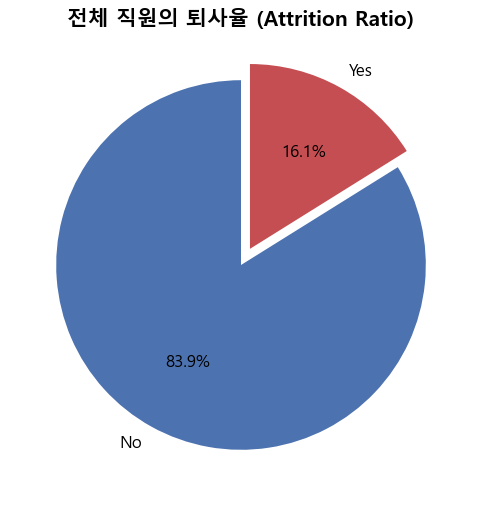

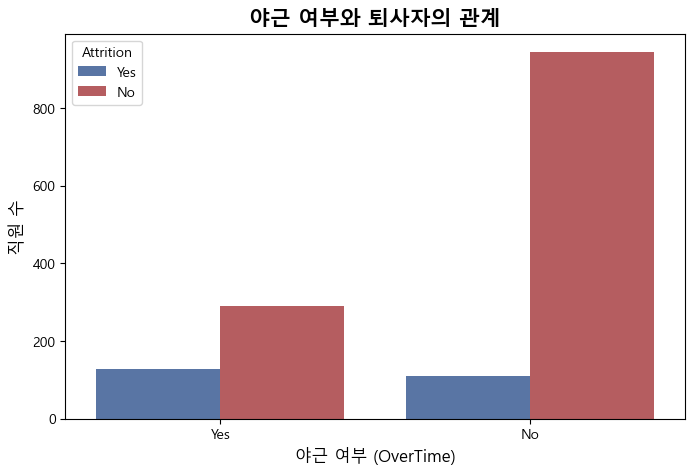

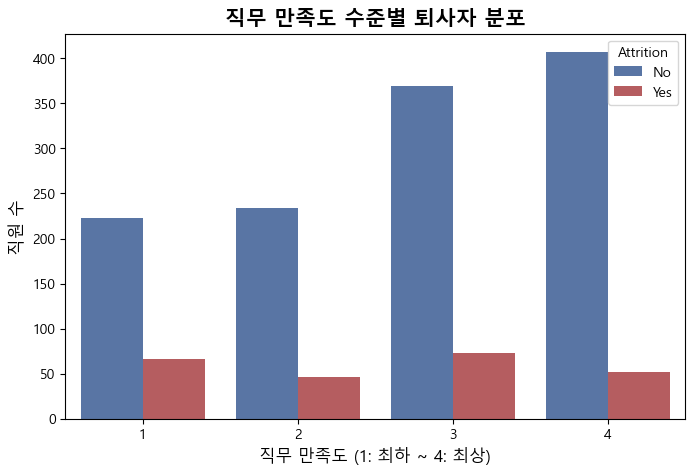

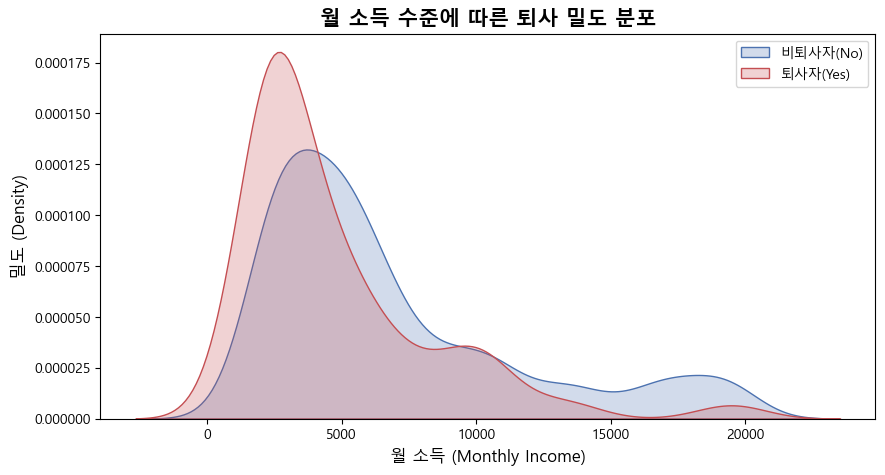

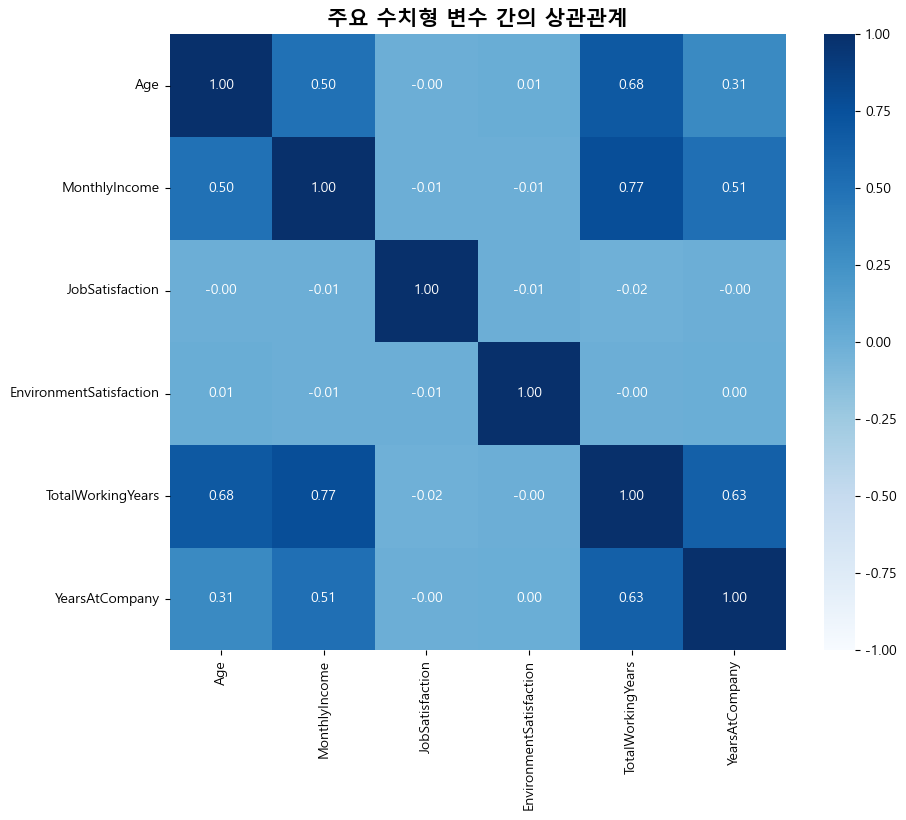

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 한글 폰트 깨짐 방지 및 폰트 선명하게 설정
plt.rcParams['font.family'] = 'Malgun Gothic' # 맥(Mac) 사용 시 'AppleGothic'으로 변경
plt.rcParams['axes.unicode_minus'] = False

# 데이터 불러오기
df = pd.read_csv('data_team7.csv')

# ==========================================
# 📊 [그래프 1] 퇴사자 vs 비퇴사자 비율 (클래스 불균형 증명)
# ==========================================
plt.figure(figsize=(6, 6))
# 'No'와 'Yes'의 개수를 세어 파이 차트로 그림
df['Attrition'].value_counts().plot.pie(
    autopct='%1.1f%%', 
    colors=['#4C72B0', '#C44E52'], 
    explode=(0, 0.1), # 퇴사자(Yes) 파이를 살짝 떼어내서 강조
    startangle=90,
    textprops={'fontsize': 12}
)
plt.title('전체 직원의 퇴사율 (Attrition Ratio)', fontsize=15, fontweight='bold')
plt.ylabel('')
plt.show()

# ==========================================
# 📊 [그래프 2] 야근(OverTime) 여부에 따른 퇴사율
# ==========================================
plt.figure(figsize=(8, 5))
sns.countplot(x='OverTime', hue='Attrition', data=df, palette=['#4C72B0', '#C44E52'])
plt.title('야근 여부와 퇴사자의 관계', fontsize=15, fontweight='bold')
plt.xlabel('야근 여부 (OverTime)', fontsize=12)
plt.ylabel('직원 수', fontsize=12)
plt.show()

# ==========================================
# 📊 [그래프 3] 직무 만족도(JobSatisfaction)가 퇴사에 미치는 영향
# ==========================================
# 1: Low, 2: Medium, 3: High, 4: Very High
plt.figure(figsize=(8, 5))
sns.countplot(x='JobSatisfaction', hue='Attrition', data=df, palette=['#4C72B0', '#C44E52'])
plt.title('직무 만족도 수준별 퇴사자 분포', fontsize=15, fontweight='bold')
plt.xlabel('직무 만족도 (1: 최하 ~ 4: 최상)', fontsize=12)
plt.ylabel('직원 수', fontsize=12)
plt.show()

# ==========================================
# 📊 [그래프 4] 월 소득(MonthlyIncome) 분포 (퇴사자 vs 비퇴사자)
# ==========================================
plt.figure(figsize=(10, 5))
sns.kdeplot(df[df['Attrition'] == 'No']['MonthlyIncome'], label='비퇴사자(No)', fill=True, color='#4C72B0')
sns.kdeplot(df[df['Attrition'] == 'Yes']['MonthlyIncome'], label='퇴사자(Yes)', fill=True, color='#C44E52')
plt.title('월 소득 수준에 따른 퇴사 밀도 분포', fontsize=15, fontweight='bold')
plt.xlabel('월 소득 (Monthly Income)', fontsize=12)
plt.ylabel('밀도 (Density)', fontsize=12)
plt.legend()
plt.show()

# ==========================================
# 📊 [그래프 5] 주요 변수 간의 상관관계 히트맵 (Correlation Heatmap)
# ==========================================
plt.figure(figsize=(10, 8))
# 수치형 데이터만 골라내어 상관계수 계산
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df[['Age', 'MonthlyIncome', 'JobSatisfaction', 'EnvironmentSatisfaction', 'TotalWorkingYears', 'YearsAtCompany']].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', vmin=-1, vmax=1, square=True)
plt.title('주요 수치형 변수 간의 상관관계', fontsize=15, fontweight='bold')
plt.show()


### LightGBM (맡은 파트)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[13]	valid_0's auc: 0.790404	valid_0's binary_logloss: 0.42465


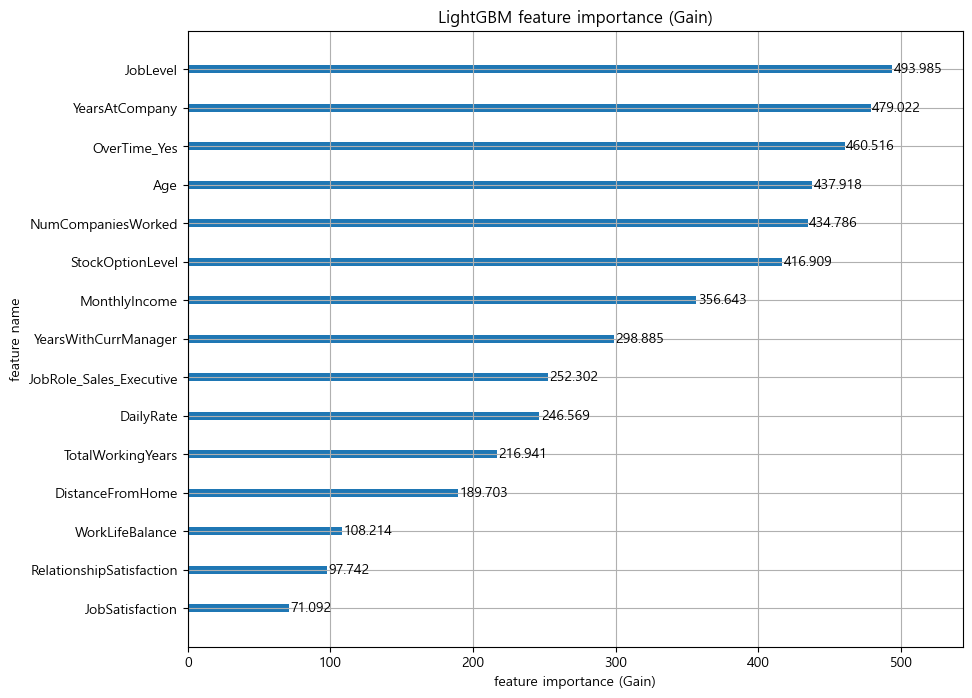


원본 데이터 & 최적 커트라인(0.26) 적용 결과
[오차 행렬]
진짜 비퇴사자(TN): 182 | 가짜 퇴사자(FP): 65
가짜 비퇴사자(FN): 15  | 진짜 퇴사자(TP): 32

▶ 정확도 (Accuracy)  : 0.7279
▶ 정밀도 (Precision) : 0.3299
▶ 재현율 (Recall)    : 0.6809 🚀
▶ F1-Score          : 0.4444
▶ ROC-AUC           : 0.7371


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix

# 1. 데이터 불러오기 및 분할 (전처리x)
df = pd.read_csv('data_team7.csv')
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_encoded = pd.get_dummies(X, drop_first=True)

# 데이터셋 split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

# ==========================================
# 2.LightGBM 모델 학습 

# 실제 비퇴사자(1233) / 퇴사자(237) 비율 계산
pos_weight = (y_train == 0).sum() / (y_train == 1).sum() 

lgbm = lgb.LGBMClassifier(
    max_depth=3,
    num_leaves=7,
    learning_rate=0.03,
    n_estimators=500,
    colsample_bytree=0.6,
    min_child_samples=20,
    reg_alpha=0.1,
    scale_pos_weight=pos_weight,
    random_state=42
    )
callbacks = [lgb.early_stopping(stopping_rounds=50)]

lgbm.fit(X_train, y_train, eval_set=[(X_val, y_val)],eval_metric='auc', callbacks=callbacks)

# ==========================================
# 3. 최적 커트라인 자동 탐색
y_pred_proba = lgbm.predict_proba(X_test)[:, 1]

best_threshold = 0.5
best_f1 = 0

# 0.10부터 0.90까지 0.01씩 커트라인을 바꿔가며 최적의 지점 탐색
for thresh in np.arange(0.1, 0.9, 0.01):
    preds = (y_pred_proba >= thresh).astype(int)
    f1 = f1_score(y_test, preds, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

# ==========================================
# 4. feature importance 시각화

fig, ax = plt.subplots(figsize=(10, 8))
lgb.plot_importance(
    lgbm, 
    max_num_features=15,       # 상위 15개 변수
    importance_type='gain',
    ax=ax,                
    title='LightGBM feature importance (Gain)', 
    xlabel='feature importance (Gain)', 
    ylabel='feature name'
)
plt.show()

# ==========================================
# 5. 최종 평가 출력

print("\n" + "="*40)
print(f"원본 데이터 & 최적 커트라인({best_threshold:.2f}) 적용 결과")
print("="*40)

y_pred_best = (y_pred_proba >= best_threshold).astype(int)
conf_matrix = confusion_matrix(y_test, y_pred_best)

print("[오차 행렬]")
print(f"진짜 비퇴사자(TN): {conf_matrix[0][0]} | 가짜 퇴사자(FP): {conf_matrix[0][1]}")
print(f"가짜 비퇴사자(FN): {conf_matrix[1][0]}  | 진짜 퇴사자(TP): {conf_matrix[1][1]}\n")

print(f"▶ 정확도 (Accuracy)  : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"▶ 정밀도 (Precision) : {precision_score(y_test, y_pred_best, zero_division=0):.4f}")
print(f"▶ 재현율 (Recall)    : {recall_score(y_test, y_pred_best):.4f} 🚀")
print(f"▶ F1-Score          : {f1_score(y_test, y_pred_best):.4f}")
print(f"▶ ROC-AUC           : {roc_auc_score(y_test, y_pred_proba):.4f}")

### 밑으로는 다른 파트 실험, Gemini 원본

로지스틱회귀

In [27]:
from sklearn.linear_model import LogisticRegression
"""from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np
import pandas as pd"""

# ==========================================
# [Step 1~3] 데이터 불러오기 및 분할 (원본 그대로 유지)
# ==========================================
df = pd.read_csv('data_team7.csv')
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_encoded = pd.get_dummies(X, drop_first=True)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_encoded), columns=X_encoded.columns)

# 불균형 유지를 위한 층화추출(Stratify) 필수 적용
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

# ==========================================
# [Step 4] 로지스틱 회귀 모델 학습
# ==========================================
print("로지스틱 회귀 모델 학습을 시작합니다...\n")

# LightGBM의 scale_pos_weight 역할 
# class_weight='balanced'를 넣으면 데이터 비율을 스스로 계산해서 소수 클래스(퇴사자)에 가중치를 부여합니다.
lr_model = LogisticRegression(
    class_weight='balanced', 
    max_iter=1000,           # 데이터가 많거나 복잡할 때 충분히 계산하도록 허용 (기본값 100은 종종 에러 발생)
    random_state=42
)

# 로지스틱 회귀는 딥러닝이나 트리 모델처럼 '반복하며 성장'하는 방식이 아니라 
# 수학 방정식을 한 번에 푸는 방식이므로 조기 종료(Early Stopping)나 검증 세트(eval_set)가 필요 없습니다.
lr_model.fit(X_train, y_train)

# ==========================================
# [Step 5] 최적의 커트라인 자동 탐색 및 최종 평가
# ==========================================
# 퇴사할 확률 추출
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]

best_threshold_lr = 0.5
best_f1_lr = 0

# 0.10부터 0.90까지 0.01씩 커트라인을 바꿔가며 최적의 지점 탐색
for thresh in np.arange(0.1, 0.9, 0.01):
    preds = (y_pred_proba_lr >= thresh).astype(int)
    f1 = f1_score(y_test, preds, zero_division=0)
    if f1 > best_f1_lr:
        best_f1_lr = f1
        best_threshold_lr = thresh

print("="*40)
print(f"🏆 로지스틱 회귀 & 최적 커트라인({best_threshold_lr:.2f}) 적용 결과")
print("="*40)

y_pred_best_lr = (y_pred_proba_lr >= best_threshold_lr).astype(int)
conf_matrix_lr = confusion_matrix(y_test, y_pred_best_lr)

print("[오차 행렬]")
print(f"진짜 비퇴사자(TN): {conf_matrix_lr[0][0]} | 가짜 퇴사자(FP): {conf_matrix_lr[0][1]}")
print(f"가짜 비퇴사자(FN): {conf_matrix_lr[1][0]}  | 진짜 퇴사자(TP): {conf_matrix_lr[1][1]}\n")

print(f"▶ 정확도 (Accuracy)  : {accuracy_score(y_test, y_pred_best_lr):.4f}")
print(f"▶ 정밀도 (Precision) : {precision_score(y_test, y_pred_best_lr, zero_division=0):.4f}")
print(f"▶ 재현율 (Recall)    : {recall_score(y_test, y_pred_best_lr):.4f} 🚀")
print(f"▶ F1-Score          : {f1_score(y_test, y_pred_best_lr):.4f}")
print(f"▶ ROC-AUC           : {roc_auc_score(y_test, y_pred_proba_lr):.4f}")

로지스틱 회귀 모델 학습을 시작합니다...

🏆 로지스틱 회귀 & 최적 커트라인(0.57) 적용 결과
[오차 행렬]
진짜 비퇴사자(TN): 207 | 가짜 퇴사자(FP): 40
가짜 비퇴사자(FN): 16  | 진짜 퇴사자(TP): 31

▶ 정확도 (Accuracy)  : 0.8095
▶ 정밀도 (Precision) : 0.4366
▶ 재현율 (Recall)    : 0.6596 🚀
▶ F1-Score          : 0.5254
▶ ROC-AUC           : 0.7894


랜덤포레스트

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np
import pandas as pd
# ==========================================
# [Step 1~3] 데이터 불러오기 및 분할 (원본 그대로 유지)
# ==========================================
df = pd.read_csv('data_team7.csv')
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_encoded = pd.get_dummies(X, drop_first=True)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_encoded), columns=X_encoded.columns)

# 불균형 유지를 위한 층화추출(Stratify) 필수 적용
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

# ==========================================
# [Step 4] 랜덤 포레스트 모델 학습
# ==========================================
print("랜덤 포레스트 모델 학습을 시작합니다...\n")

# 랜덤 포레스트는 수백 개의 트리가 다수결 투표를 하므로 검증 데이터(Early Stopping)가 필요 없습니다.
rf_model = RandomForestClassifier(
    n_estimators=500,        # 500개의 나무를 심어 숲을 만듭니다.
    max_depth=5,             # 각 나무의 깊이를 5로 제한하여 지엽적인 암기(과적합)를 방어합니다.
    class_weight='balanced', # 불균형 해소: 퇴사자(소수) 의견에 더 큰 가중치를 부여합니다.
    n_jobs=-1,               # 노트북의 모든 CPU 코어를 사용하여 빠르게 학습시킵니다.
    random_state=42
)

# 훈련 데이터로 바로 학습 진행
rf_model.fit(X_train, y_train)

# ==========================================
# [Step 5] 최적의 커트라인 자동 탐색 및 최종 평가
# ==========================================
# 퇴사할 확률 추출
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

best_threshold_rf = 0.5
best_f1_rf = 0

# 0.10부터 0.90까지 0.01씩 커트라인을 바꿔가며 최적의 F1-Score 지점 탐색
for thresh in np.arange(0.1, 0.9, 0.01):
    preds = (y_pred_proba_rf >= thresh).astype(int)
    f1 = f1_score(y_test, preds, zero_division=0)
    if f1 > best_f1_rf:
        best_f1_rf = f1
        best_threshold_rf = thresh

print("="*40)
print(f"🏆 랜덤 포레스트 & 최적 커트라인({best_threshold_rf:.2f}) 적용 결과")
print("="*40)

y_pred_best_rf = (y_pred_proba_rf >= best_threshold_rf).astype(int)
conf_matrix_rf = confusion_matrix(y_test, y_pred_best_rf)

print("[오차 행렬]")
print(f"진짜 비퇴사자(TN): {conf_matrix_rf[0][0]} | 가짜 퇴사자(FP): {conf_matrix_rf[0][1]}")
print(f"가짜 비퇴사자(FN): {conf_matrix_rf[1][0]}  | 진짜 퇴사자(TP): {conf_matrix_rf[1][1]}\n")

print(f"▶ 정확도 (Accuracy)  : {accuracy_score(y_test, y_pred_best_rf):.4f}")
print(f"▶ 정밀도 (Precision) : {precision_score(y_test, y_pred_best_rf, zero_division=0):.4f}")
print(f"▶ 재현율 (Recall)    : {recall_score(y_test, y_pred_best_rf):.4f} 🚀")
print(f"▶ F1-Score          : {f1_score(y_test, y_pred_best_rf):.4f}")
print(f"▶ ROC-AUC           : {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

랜덤 포레스트 모델 학습을 시작합니다...

🏆 랜덤 포레스트 & 최적 커트라인(0.42) 적용 결과
[오차 행렬]
진짜 비퇴사자(TN): 197 | 가짜 퇴사자(FP): 50
가짜 비퇴사자(FN): 16  | 진짜 퇴사자(TP): 31

▶ 정확도 (Accuracy)  : 0.7755
▶ 정밀도 (Precision) : 0.3827
▶ 재현율 (Recall)    : 0.6596 🚀
▶ F1-Score          : 0.4844
▶ ROC-AUC           : 0.7582


XGBoost

In [29]:
import xgboost as xgb
"""from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd"""
# ==========================================
# [Step 1~3] 데이터 불러오기 및 분할 (원본 그대로 유지)
# ==========================================
df = pd.read_csv('data_team7.csv')
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_encoded = pd.get_dummies(X, drop_first=True)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_encoded), columns=X_encoded.columns)

# 불균형 유지를 위한 층화추출(Stratify) 필수 적용
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

# ==========================================
# [Step 4] XGBoost 모델 학습
# ==========================================
print("XGBoost 모델 학습을 시작합니다...\n")

# 실제 비퇴사자 / 퇴사자 비율 계산 (LightGBM과 동일한 가중치 적용)
pos_weight = (y_train == 0).sum() / (y_train == 1).sum() 

xgb_model = xgb.XGBClassifier(
    max_depth=3,                 # 얕은 트리로 과적합 방어
    learning_rate=0.03,          # 천천히 학습
    n_estimators=500,            # 최대 500개의 트리 생성
    scale_pos_weight=pos_weight, # 불균형 해소를 위한 가중치 부여
    colsample_bytree=0.6,        # 피처의 60%만 사용하여 다양한 변수 탐색 (과적합 방지)
    subsample=0.8,               # 데이터의 80%만 무작위로 추출하여 학습 (과적합 방지)
    random_state=42,
    early_stopping_rounds=50,    # 50번 동안 검증 점수가 안 오르면 조기 종료
    eval_metric='auc'            # 평가 지표는 불균형 데이터에 맞는 AUC
)

# 학습 실행 (XGBoost는 LightGBM과 달리 early_stopping_rounds를 모델 선언부나 fit에 직관적으로 넣습니다)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False  # 학습 과정 출력 생략 (보고 싶다면 True로 변경)
)

# ==========================================
# [Step 5] 최적의 커트라인 자동 탐색 및 최종 평가
# ==========================================
# 퇴사할 확률 추출
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

best_threshold_xgb = 0.5
best_f1_xgb = 0

# 0.10부터 0.90까지 0.01씩 커트라인을 바꿔가며 최적의 지점 탐색
for thresh in np.arange(0.1, 0.9, 0.01):
    preds = (y_pred_proba_xgb >= thresh).astype(int)
    f1 = f1_score(y_test, preds, zero_division=0)
    if f1 > best_f1_xgb:
        best_f1_xgb = f1
        best_threshold_xgb = thresh

print("="*40)
print(f"🏆 XGBoost & 최적 커트라인({best_threshold_xgb:.2f}) 적용 결과")
print("="*40)

y_pred_best_xgb = (y_pred_proba_xgb >= best_threshold_xgb).astype(int)
conf_matrix_xgb = confusion_matrix(y_test, y_pred_best_xgb)

print("[오차 행렬]")
print(f"진짜 비퇴사자(TN): {conf_matrix_xgb[0][0]} | 가짜 퇴사자(FP): {conf_matrix_xgb[0][1]}")
print(f"가짜 비퇴사자(FN): {conf_matrix_xgb[1][0]}  | 진짜 퇴사자(TP): {conf_matrix_xgb[1][1]}\n")

print(f"▶ 정확도 (Accuracy)  : {accuracy_score(y_test, y_pred_best_xgb):.4f}")
print(f"▶ 정밀도 (Precision) : {precision_score(y_test, y_pred_best_xgb, zero_division=0):.4f}")
print(f"▶ 재현율 (Recall)    : {recall_score(y_test, y_pred_best_xgb):.4f} 🚀")
print(f"▶ F1-Score          : {f1_score(y_test, y_pred_best_xgb):.4f}")
print(f"▶ ROC-AUC           : {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")

XGBoost 모델 학습을 시작합니다...

🏆 XGBoost & 최적 커트라인(0.50) 적용 결과
[오차 행렬]
진짜 비퇴사자(TN): 197 | 가짜 퇴사자(FP): 50
가짜 비퇴사자(FN): 19  | 진짜 퇴사자(TP): 28

▶ 정확도 (Accuracy)  : 0.7653
▶ 정밀도 (Precision) : 0.3590
▶ 재현율 (Recall)    : 0.5957 🚀
▶ F1-Score          : 0.4480
▶ ROC-AUC           : 0.7592
